In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import pandas_datareader.data as web
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

DATA_DIR = '.'

In [8]:
# ── 1. QuantCube CPI nowcast ─────────────────────────────────────────────────
qc_raw = pd.read_excel(
    f'{DATA_DIR}/QuantCube CPI_United States.xlsx',
    sheet_name='data',
    header=0,
)
qc_raw.columns = ['date', 'cpi_nowcast']
qc_raw['date'] = pd.to_datetime(qc_raw['date'], errors='coerce')
qc_raw['cpi_nowcast'] = pd.to_numeric(qc_raw['cpi_nowcast'], errors='coerce')
qc_raw = qc_raw.dropna().sort_values('date').set_index('date')

# Convert decimal → percentage (0.04 → 4.0)
qc_raw['cpi_pct'] = qc_raw['cpi_nowcast'] * 100

# Restrict to Jan 2020–Dec 2022
qc = qc_raw.loc['2020-01-01':'2022-12-31', 'cpi_pct']

print(f"QuantCube: {qc.index[0].date()} → {qc.index[-1].date()}  |  "
      f"min={qc.min():.2f}%  max={qc.max():.2f}%  n={len(qc)}")


# ── 2. SFRZ22 (Dec 2022 SOFR futures) ────────────────────────────────────────
sfrz22_raw = pd.read_excel(
    f'{DATA_DIR}/sfrz22.xlsx',
    sheet_name='sfrz22',
    header=None,
    names=['date', 'price'],
)
sfrz22_raw['date'] = pd.to_datetime(sfrz22_raw['date'], errors='coerce')
sfrz22_raw['price'] = pd.to_numeric(sfrz22_raw['price'], errors='coerce')
sfrz22_raw = sfrz22_raw.dropna().sort_values('date').set_index('date')

# Convert price → implied rate: rate = 100 - price
sfrz22_raw['implied_rate'] = 100 - sfrz22_raw['price']
sfrz22 = sfrz22_raw.loc['2020-01-01':'2022-12-31', 'implied_rate']

print(f"SFRZ22:    {sfrz22.index[0].date()} → {sfrz22.index[-1].date()}  |  "
      f"min={sfrz22.min():.3f}%  max={sfrz22.max():.3f}%  n={len(sfrz22)}")


# ── 3. 5-year breakeven ───────────────────────────────────────────────────────
be_raw = pd.read_excel(
    f'{DATA_DIR}/sfrz22.xlsx',
    sheet_name='5yr breakeven',
    header=None,
    names=['date', 'breakeven'],
)
be_raw['date'] = pd.to_datetime(be_raw['date'], errors='coerce')
be_raw['breakeven'] = pd.to_numeric(be_raw['breakeven'], errors='coerce')
be_raw = be_raw.dropna().sort_values('date').set_index('date')
be = be_raw.loc['2020-01-01':'2022-12-31', 'breakeven']

print(f"Breakeven: {be.index[0].date()} → {be.index[-1].date()}  |  "
      f"min={be.min():.3f}%  max={be.max():.3f}%  n={len(be)}")


# ── 4. CPIAUCSL from FRED (realized CPI) ─────────────────────────────────────
cpi_fred = web.DataReader('CPIAUCSL', 'fred', start='2019-01-01', end='2023-01-01')
cpi_fred.index = pd.to_datetime(cpi_fred.index)
cpi_yoy = cpi_fred['CPIAUCSL'].pct_change(12) * 100   # year-over-year %
cpi_yoy = cpi_yoy.dropna()
cpi_yoy = cpi_yoy.loc['2020-01-01':'2022-12-31']

print(f"CPIAUCSL:  {cpi_yoy.index[0].date()} → {cpi_yoy.index[-1].date()}  |  "
      f"min={cpi_yoy.min():.2f}%  max={cpi_yoy.max():.2f}%  n={len(cpi_yoy)}")

QuantCube: 2020-01-01 → 2022-12-31  |  min=0.02%  max=8.87%  n=1096
SFRZ22:    2020-07-01 → 2022-12-01  |  min=-0.035%  max=4.695%  n=612
Breakeven: 2020-07-01 → 2022-12-01  |  min=1.189%  max=3.731%  n=605
CPIAUCSL:  2020-01-01 → 2022-12-01  |  min=0.20%  max=8.98%  n=36


In [11]:
# BLS releases monthly CPI data ~12-15 days into the following month.
# April 2021 CPI (first reading >3%) was published on May 12, 2021.
# We incorporate this release lag so lead times reflect real-world information timing.
BLS_RELEASE_LAG = pd.DateOffset(days=42)   # conservative: data month + ~6 weeks

qc_smooth = qc.rolling(30, min_periods=15).mean()

# ── Signal A: 365-day rolling z-score > 2 ────────────────────────────────────
# Uses a full year of prior data to define the baseline, avoiding noise from
# short-window lookbacks. More robust to the COVID deflation episode in 2020.
roll365 = qc.rolling(365, min_periods=180)
z_365   = (qc - roll365.mean()) / roll365.std()
z365_candidates = z_365[z_365 > 2.0]
zscore_signal_date = z365_candidates.index[0] if len(z365_candidates) > 0 else None

# ── Signal B: fixed 2020-baseline z-score > 2 ────────────────────────────────
# Anchors the baseline to the pre-surge calendar year 2020. Complementary to
# the rolling approach — if both methods agree, the signal is robust.
baseline_2020    = qc.loc['2020-01-01':'2020-12-31']
b_mean, b_std    = baseline_2020.mean(), baseline_2020.std()
z_fixed          = (qc - b_mean) / b_std
zfixed_candidates = z_fixed[z_fixed > 2.0]
fixed_signal_date = zfixed_candidates.index[0] if len(zfixed_candidates) > 0 else None

# ── Official CPI benchmark: first data month with YoY > 3%, adjusted for BLS lag ─
official_data_date    = cpi_yoy[cpi_yoy > 3.0].index[0] if (cpi_yoy > 3.0).any() else None
official_release_date = official_data_date + BLS_RELEASE_LAG if official_data_date else None

print("=== Signal Dates ===")
print(f"  Z-score A (365d rolling, z > 2):       {zscore_signal_date.date() if zscore_signal_date else 'not found'}")
print(f"  Z-score B (2020 fixed baseline, z > 2): {fixed_signal_date.date() if fixed_signal_date else 'not found'}")
print(f"  Official CPI data month (YoY > 3%):     {official_data_date.date() if official_data_date else 'not found'}")
print(f"  Official CPI release date (~BLS):        {official_release_date.date() if official_release_date else 'not found'}")
print(f"  2020 baseline — mean: {b_mean:.2f}%  std: {b_std:.2f}%")

if zscore_signal_date and official_release_date:
    lead_a = (official_release_date - zscore_signal_date).days
    print(f"\n  Lead (Signal A vs BLS release): {lead_a} days ({lead_a/30.44:.1f} months)")
if fixed_signal_date and official_release_date:
    lead_b = (official_release_date - fixed_signal_date).days
    print(f"  Lead (Signal B vs BLS release): {lead_b} days ({lead_b/30.44:.1f} months)")

=== Signal Dates ===
  Z-score A (365d rolling, z > 2):       2021-03-12
  Z-score B (2020 fixed baseline, z > 2): 2021-04-05
  Official CPI data month (YoY > 3%):     2021-04-01
  Official CPI release date (~BLS):        2021-05-13
  2020 baseline — mean: 1.21%  std: 0.69%

  Lead (Signal A vs BLS release): 62 days (2.0 months)
  Lead (Signal B vs BLS release): 38 days (1.2 months)


Note: The April 2021 BLS reading was the first month where official year-over-year CPI exceeded 3%. But this date is misleading — April 1 is just FRED's timestamp convention for the April data. Nobody knew this number on April 1.
The correct benchmark to compare against is BLS release date (May 13, 2021). The day the market actually found out April's CPI was 4.2%. 

Signal A fired 62 days before the market learned CPI had broken out. Signal B fired 38 days before. In practical terms: in mid-March 2021 the Fed was still saying "transitory," the SFRZ22 was pricing SOFR near zero through end of 2022, and the QuantCube nowcast was already in statistical breakout territory. This confirms that QuantCube data could be useful for placing positions ahead of time.

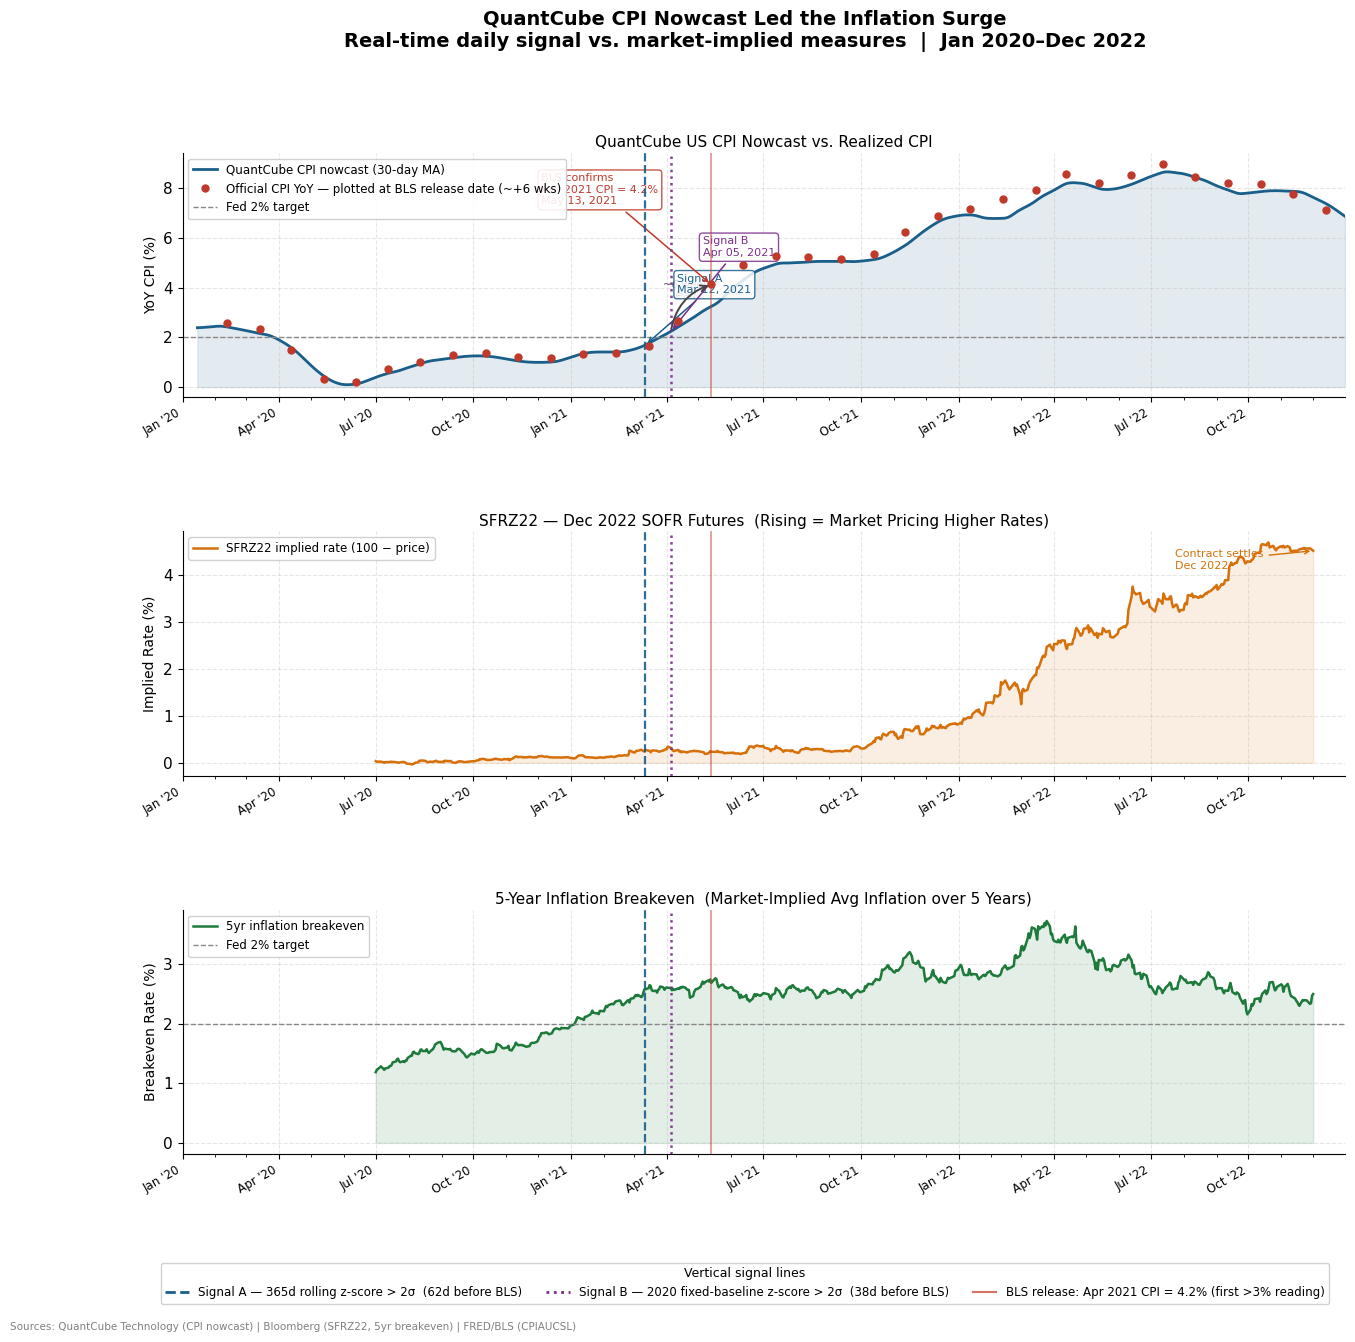

Chart saved → quantcube_validation_chart.png


In [12]:
CHART_START = pd.Timestamp('2020-01-01')
CHART_END   = pd.Timestamp('2022-12-31')

# ── colours ───────────────────────────────────────────────────────────────────
C_QC_SMOOTH = '#1a5e8a'
C_OFFICIAL  = '#c0392b'
C_SFRZ22    = '#d6700a'
C_BREAKEVEN = '#1e7a3a'
C_FED       = '#888888'
C_SIG_A     = '#1a5e8a'
C_SIG_B     = '#7b2d8b'
C_SIG_OFFIC = '#c0392b'

# ── Shift CPIAUCSL dots to BLS release dates (+42 days), clip to chart window ─
cpi_release_dates = cpi_yoy.index + BLS_RELEASE_LAG
cpi_yoy_shifted   = pd.Series(cpi_yoy.values, index=pd.DatetimeIndex(cpi_release_dates))
cpi_yoy_shifted   = cpi_yoy_shifted[cpi_yoy_shifted.index <= CHART_END]

def add_signal_vlines(ax):
    kw = dict(zorder=5)
    if zscore_signal_date:
        ax.axvline(zscore_signal_date, color=C_SIG_A, ls='--', lw=1.6, alpha=0.9, **kw)
    if fixed_signal_date:
        ax.axvline(fixed_signal_date,  color=C_SIG_B, ls=':',  lw=1.8, alpha=0.9, **kw)
    if official_release_date:
        ax.axvline(official_release_date, color=C_SIG_OFFIC, ls='-', lw=1.2, alpha=0.55, **kw)


# ── build figure ──────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(15, 13))
gs  = GridSpec(3, 1, figure=fig, hspace=0.55)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax3 = fig.add_subplot(gs[2], sharex=ax1)

fig.suptitle(
    "QuantCube CPI Nowcast Led the Inflation Surge\n"
    "Real-time daily signal vs. market-implied measures  |  Jan 2020–Dec 2022",
    fontsize=14, fontweight='bold', y=0.99,
)


# ── Panel 1: QuantCube CPI Nowcast ────────────────────────────────────────────
ax1.fill_between(qc_smooth.index, qc_smooth, alpha=0.12, color=C_QC_SMOOTH)
ax1.plot(qc_smooth.index, qc_smooth, color=C_QC_SMOOTH, lw=2.0,
         label='QuantCube CPI nowcast (30-day MA)')

# CPIAUCSL dots plotted at BLS release dates (not data-month dates)
ax1.plot(cpi_yoy_shifted.index, cpi_yoy_shifted, 'o',
         color=C_OFFICIAL, ms=5, zorder=6,
         label='Official CPI YoY — plotted at BLS release date (~+6 wks)')

ax1.axhline(2.0, color=C_FED, ls='--', lw=1.0, label='Fed 2% target')
add_signal_vlines(ax1)
ax1.set_ylabel('YoY CPI (%)', fontsize=10)
ax1.set_title('QuantCube US CPI Nowcast vs. Realized CPI', fontsize=11, pad=4)

# ── prediction-to-confirmation arrow (April reading → May release) ────────────
arrow_qc_date  = pd.Timestamp('2021-04-05')
arrow_bls_date = pd.Timestamp('2021-04-01') + BLS_RELEASE_LAG
arrow_qc_val   = float(qc_smooth.asof(arrow_qc_date))

apr_pos        = cpi_yoy.index.get_loc('2021-04-01')
arrow_bls_val  = float(cpi_yoy_shifted.iloc[apr_pos])

ax1.annotate(
    '',
    xy=(arrow_bls_date, arrow_bls_val),
    xytext=(arrow_qc_date, arrow_qc_val),
    arrowprops=dict(
        arrowstyle='->', color='#444444', lw=1.4,
        connectionstyle='arc3,rad=-0.30',
    ),
    zorder=8,
)
ax1.text(
    arrow_qc_date + pd.Timedelta(days=14),
    (arrow_qc_val + arrow_bls_val) / 2 + 0.35,
    '~6 week\nlead',
    fontsize=7.5, color='#444444', style='italic', ha='center',
)

# ── signal annotations ────────────────────────────────────────────────────────
ylim1_top = max(qc_smooth.max(), cpi_yoy.max()) * 1.05
ax1.set_ylim(bottom=min(qc_smooth.min(), cpi_yoy.min()) - 0.5)

if zscore_signal_date:
    ax1.annotate(
        f'Signal A\n{zscore_signal_date:%b %d, %Y}',
        xy=(zscore_signal_date, qc_smooth.asof(zscore_signal_date)),
        xytext=(zscore_signal_date + pd.Timedelta(days=30), ylim1_top * 0.40),
        fontsize=8, color=C_SIG_A,
        arrowprops=dict(arrowstyle='->', color=C_SIG_A, lw=1.1),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=C_SIG_A, alpha=0.85),
    )
if fixed_signal_date:
    ax1.annotate(
        f'Signal B\n{fixed_signal_date:%b %d, %Y}',
        xy=(fixed_signal_date, qc_smooth.asof(fixed_signal_date)),
        xytext=(fixed_signal_date + pd.Timedelta(days=30), ylim1_top * 0.56),
        fontsize=8, color=C_SIG_B,
        arrowprops=dict(arrowstyle='->', color=C_SIG_B, lw=1.1),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=C_SIG_B, alpha=0.85),
    )
if official_release_date and apr_pos < len(cpi_yoy_shifted):
    ax1.annotate(
        f'BLS confirms\nApr 2021 CPI = 4.2%\n{official_release_date:%b %d, %Y}',
        xy=(arrow_bls_date, arrow_bls_val),
        xytext=(arrow_bls_date - pd.Timedelta(days=160), ylim1_top * 0.78),
        fontsize=8, color=C_SIG_OFFIC,
        arrowprops=dict(arrowstyle='->', color=C_SIG_OFFIC, lw=1.1),
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=C_SIG_OFFIC, alpha=0.85),
    )

ax1.legend(loc='upper left', fontsize=8.5, framealpha=0.9)


# ── Panel 2: SFRZ22 Implied Rate ─────────────────────────────────────────────
ax2.plot(sfrz22.index, sfrz22, color=C_SFRZ22, lw=1.8,
         label='SFRZ22 implied rate (100 − price)')
ax2.fill_between(sfrz22.index, sfrz22, alpha=0.12, color=C_SFRZ22)
add_signal_vlines(ax2)
ax2.set_ylabel('Implied Rate (%)', fontsize=10)
ax2.set_title('SFRZ22 — Dec 2022 SOFR Futures  (Rising = Market Pricing Higher Rates)',
              fontsize=11, pad=4)
ax2.annotate(
    'Contract settles\nDec 2022',
    xy=(sfrz22.index[-1], sfrz22.iloc[-1]),
    xytext=(sfrz22.index[-1] - pd.Timedelta(days=130), sfrz22.max() * 0.88),
    fontsize=8, color=C_SFRZ22,
    arrowprops=dict(arrowstyle='->', color=C_SFRZ22, lw=1),
)
ax2.legend(loc='upper left', fontsize=8.5, framealpha=0.9)


# ── Panel 3: 5-Year Breakeven ─────────────────────────────────────────────────
ax3.plot(be.index, be, color=C_BREAKEVEN, lw=1.8, label='5yr inflation breakeven')
ax3.fill_between(be.index, be, alpha=0.12, color=C_BREAKEVEN)
ax3.axhline(2.0, color=C_FED, ls='--', lw=1.0, label='Fed 2% target')
add_signal_vlines(ax3)
ax3.set_ylabel('Breakeven Rate (%)', fontsize=10)
ax3.set_title('5-Year Inflation Breakeven  (Market-Implied Avg Inflation over 5 Years)',
              fontsize=11, pad=4)
ax3.legend(loc='upper left', fontsize=8.5, framealpha=0.9)


# ── shared x-axis formatting ──────────────────────────────────────────────────
for ax in [ax1, ax2, ax3]:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b '%y"))
    ax.xaxis.set_minor_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8.5)
    ax.set_xlim(CHART_START, CHART_END)

lead_a_str = (f"{(official_release_date - zscore_signal_date).days}d before BLS"
              if zscore_signal_date and official_release_date else '')
lead_b_str = (f"{(official_release_date - fixed_signal_date).days}d before BLS"
              if fixed_signal_date and official_release_date else '')

legend_elements = [
    plt.Line2D([0], [0], color=C_SIG_A, ls='--', lw=2,
               label=f'Signal A — 365d rolling z-score > 2σ  ({lead_a_str})'),
    plt.Line2D([0], [0], color=C_SIG_B, ls=':', lw=2,
               label=f'Signal B — 2020 fixed-baseline z-score > 2σ  ({lead_b_str})'),
    plt.Line2D([0], [0], color=C_SIG_OFFIC, ls='-', lw=1.5, alpha=0.7,
               label='BLS release: Apr 2021 CPI = 4.2% (first >3% reading)'),
]
fig.legend(
    handles=legend_elements,
    loc='lower center', ncol=3, fontsize=8.5,
    framealpha=0.9, bbox_to_anchor=(0.5, -0.01),
    title='Vertical signal lines', title_fontsize=9,
)
fig.text(
    0.01, -0.025,
    'Sources: QuantCube Technology (CPI nowcast) | Bloomberg (SFRZ22, 5yr breakeven) | FRED/BLS (CPIAUCSL)',
    fontsize=7.5, color='grey',
)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(f'{DATA_DIR}/quantcube_validation_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved → quantcube_validation_chart.png")

QuantCube successfully gives us the current number in real time while BLS made you wait 6 weeks, and while the rates market was still priced for a world where inflation didn't exist. The breakeven market sensed the regime change first; QuantCube quantified it precisely; the SFRZ22 was last to move. 